In [1]:
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain_core.messages import HumanMessage, AIMessage, AnyMessage
from langchain.chat_models import init_chat_model
from langgraph.checkpoint.memory import MemorySaver
from typing import List, Optional, TypedDict, Annotated
import operator
from dotenv import load_dotenv
from pydantic import BaseModel, Field

# Load environmental variables from .env
load_dotenv()

True

In [2]:
llm = init_chat_model("gpt-4o-mini")

sqlite3_path = "./formula1.db"

## **Define state and create a graph**

In [3]:
from state import GraphState

graph = StateGraph(GraphState)




#Nodes

In [4]:
from nodes.ingest_user_message import ingest_user_message
from nodes.question_classifier import make_question_classifier_node
from nodes.check_schema_cache import check_schema_cache
from nodes.make_schema_introspector_node import make_schema_introspector_node
from nodes.schema_normalizer import schema_normalizer
from nodes.nl_to_sql_planner import make_nl_to_sql_planner_node
from nodes.make_sql_executor_node import make_sql_executor_node
from nodes.make_result_summarizer_node import make_result_summarizer_node
from nodes.schema_explainer import make_schema_explainer_node
from nodes.llm_direct_answer import make_llm_direct_answer_node
from nodes.unsupported_handler import unsupported_handler

question_classifier = make_question_classifier_node(llm)
schema_introspector = make_schema_introspector_node(sqlite3_path)
nl_to_sql_planner = make_nl_to_sql_planner_node(llm)
sql_executor = make_sql_executor_node(sqlite3_path)
result_summarizer = make_result_summarizer_node(llm)
schema_explainer = make_schema_explainer_node(llm)
llm_direct_answer = make_llm_direct_answer_node(llm)

graph.add_node("ingest_user_message", ingest_user_message)
graph.add_node("question_classifier", question_classifier)
graph.add_node("check_schema_cache", check_schema_cache)
graph.add_node("schema_explainer", schema_explainer)
graph.add_node("schema_introspector", schema_introspector)
graph.add_node("schema_normalizer", schema_normalizer)
graph.add_node("nl_to_sql_planner", nl_to_sql_planner)
graph.add_node("sql_executor", sql_executor)
graph.add_node("result_summarizer", result_summarizer)
graph.add_node("llm_direct_answer", llm_direct_answer)
graph.add_node("unsupported_handler", unsupported_handler)

Edges

In [5]:
def next_after_cache(state: GraphState) -> str:
    if not state.db_schema_ready:
        return "missing"

    # schema is ready → choose target based on question_type
    if state.question_type == "db_read":
        return "read_ready"
    elif state.question_type == "db_schema_question":
        return "schema_ready"
    else:
        # fallback, shouldn't really happen here
        return "read_ready"

def next_after_normalizer(state: GraphState) -> str:
    # same logic as above, but now schema is definitely ready
    if state.question_type == "db_schema_question":
        return "schema"
    else:
        return "read"


In [6]:
graph.add_edge(START, "ingest_user_message")
graph.add_edge("ingest_user_message", "question_classifier")

graph.add_conditional_edges(
    "check_schema_cache",
    lambda state: "ready" if state.db_schema_ready else "missing",
    {
        "ready": "nl_to_sql_planner",
        "missing": "schema_introspector",
    },
)

graph.add_conditional_edges(
    "question_classifier",
    lambda s: s.question_type,
    {
        "db_read": "check_schema_cache",
        "db_schema_question": "check_schema_cache",  # reuse cache logic
        "chitchat": "llm_direct_answer",             # if you added this
        "unsupported": "unsupported_handler",
    },
)

graph.add_conditional_edges(
    "check_schema_cache",
    next_after_cache,
    {
        "missing": "schema_introspector",
        "read_ready": "nl_to_sql_planner",
        "schema_ready": "schema_explainer",
    },
)

graph.add_conditional_edges(
    "schema_normalizer",
    next_after_normalizer,
    {
        "schema": "schema_explainer",
        "read": "nl_to_sql_planner",
    },
)

graph.add_edge("schema_introspector", "schema_normalizer")
graph.add_edge("schema_normalizer", "nl_to_sql_planner")
graph.add_edge("nl_to_sql_planner", "sql_executor")
graph.add_edge("sql_executor", "result_summarizer")
graph.add_edge("result_summarizer", END)
graph.add_edge("llm_direct_answer", END)
graph.add_edge("unsupported_handler", END)

checkpointer = MemorySaver()
app = graph.compile(checkpointer=checkpointer)

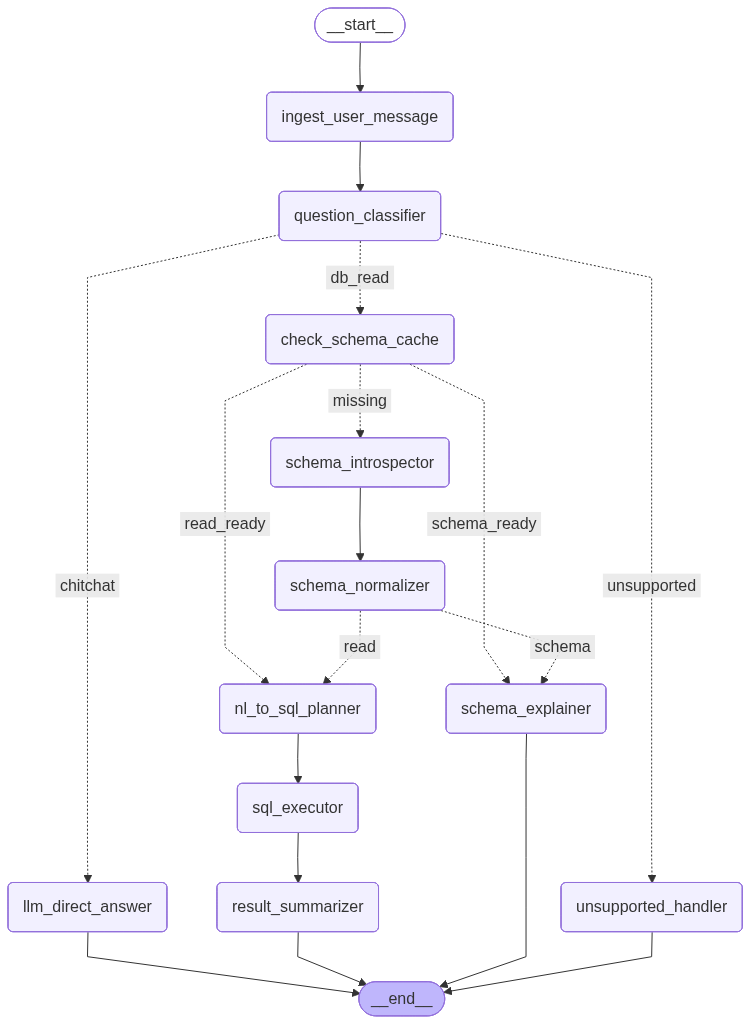

In [7]:
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [8]:
import pprint
import traceback
import gradio as gr
from uuid import uuid4

def chat_fn(message: str, history: list, session_id: str):
    """
    Gradio callback.

    - message: latest user input
    - history: list of (user, bot) tuples from ChatInterface
    - session_id: unique thread id per user session
    """
    try:
        # Invoke the graph with a single new HumanMessage.
        # LangGraph will accumulate messages internally thanks to the `messages` reducer.
        result = app.invoke(
            {"messages": [HumanMessage(content=message)]},
            config={"configurable": {"thread_id": session_id}},
        )
        pprint.pp(result)
        # result is a GraphState instance → convert to dict for convenience
        answer = result.get("final_answer") or "I couldn't generate an answer."


        # ---- Debug view ----
        # Pull out interesting internal fields from GraphState
        question_type = result.get("question_type")
        db_schema_ready = result.get("db_schema_ready")
        sql_query = result.get("sql_query")
        sql_explanation = result.get("sql_explanation")
        execution_error = result.get("execution_error")
        query_metadata = result.get("query_metadata")
        assumptions = result.get("assumptions")
        db_schema_summary = result.get("db_schema_summary")

        debug_blocks = [
            "### 🐛 Debug info",
            "",
            f"**question_type**: `{question_type}`",
            f"**db_schema_ready**: `{db_schema_ready}`",
            f"**execution_error**: `{execution_error}`",
            "",
        ]

        if sql_query:
            debug_blocks.append("**Generated SQL:**")
            debug_blocks.append("```sql")
            debug_blocks.append(sql_query)
            debug_blocks.append("```")

        if sql_explanation:
            debug_blocks.append("**SQL explanation:**")
            debug_blocks.append(sql_explanation)

        if assumptions:
            debug_blocks.append("**Assumptions:**")
            for a in assumptions:
                debug_blocks.append(f"- {a}")

        if query_metadata:
            debug_blocks.append("**Query metadata:**")
            debug_blocks.append(f"- row_count: {query_metadata.get('row_count')}")
            debug_blocks.append(f"- columns: {query_metadata.get('columns')}")

        if db_schema_summary:
            # Don't spam the whole thing, just the first few lines
            lines = db_schema_summary.splitlines()
            preview = "\n".join(lines[:8])
            debug_blocks.append("**DB schema summary (preview):**")
            debug_blocks.append("```text")
            debug_blocks.append(preview)
            debug_blocks.append("```")

        debug_text = "\n".join(debug_blocks)
    except Exception as e:
        # Log full traceback to your terminal
        traceback.print_exc()
        return f"Internal error: {e}"

    # Combine user-facing answer + debug panel
    return answer + "\n\n---\n\n" + debug_text

with gr.Blocks() as demo:
    gr.Markdown("# 🧠 DB QA Agent (LangGraph + Gradio + SQLite)")

    # One session_id per browser session
    session_state = gr.State(str(uuid4()))

    chat = gr.ChatInterface(
        fn=chat_fn,
        additional_inputs=[session_state],
        chatbot=gr.Chatbot(
            label="DB Agent",
            height=300,
            type="messages"
        ),
        textbox=gr.Textbox(
            placeholder="Ask things like: 'Who are the top 10 customers by revenue?'",
            label="Your question",
        ),
        title="",
        description="Ask questions about the data stored in the SQLite database.",
    )

C:\Users\kuba\projects\formula1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\kuba\projects\formula1\.venv\Lib\site-packages\gradio\chat_interface.py:331: UserWarning: The gr.ChatInterface was not provided with a type, so the type of the gr.Chatbot, 'messages', will be used.
  warnings.warn(


In [9]:
demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [10]:
state = graph.__getstate__()['channels']
state['db_schema']